In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
painting_info = pd.read_csv("../data/mondrian-painting-info.csv")
painting_features = pd.read_csv("../data/mondrian-painting-features.csv")
fp26_features = pd.read_csv("../data/fp26-features.csv")

In [6]:
painting_info.head()

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750


In [7]:
painting_features.head()

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16


In [8]:
fp26_features.head()

,painting_id,feature,x,y,width,height,color,rgb
0,fp26,rect,0,0,34,92,white,#fafafa
1,fp26,rect,41,0,267,22,white,#f9f9f9
2,fp26,rect,317,0,309,22,white,#fafafa
3,fp26,rect,634,0,38,261,white,#fafafa
4,fp26,rect,680,0,32,261,yellow,#fcf202


In [9]:
painting_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   painting_id  136 non-null    str  
 1   year         136 non-null    int64
 2   title        136 non-null    str  
 3   width        136 non-null    int64
 4   height       136 non-null    int64
dtypes: int64(3), str(2)
memory usage: 5.4 KB


In [10]:
painting_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   painting_id  3204 non-null   str  
 1   feature      3204 non-null   str  
 2   x            3204 non-null   int64
 3   y            3204 non-null   int64
 4   width        3204 non-null   int64
 5   height       3204 non-null   int64
 6   color        3204 non-null   str  
 7   rgb          3204 non-null   str  
dtypes: int64(4), str(4)
memory usage: 200.4 KB


In [11]:
fp26_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   painting_id  54 non-null     str  
 1   feature      54 non-null     str  
 2   x            54 non-null     int64
 3   y            54 non-null     int64
 4   width        54 non-null     int64
 5   height       54 non-null     int64
 6   color        54 non-null     str  
 7   rgb          54 non-null     str  
dtypes: int64(4), str(4)
memory usage: 3.5 KB


In [12]:
painting_info.describe()

,year,width,height
count,136.000000,136.000000,136.000000
mean,1929.102941,541.213235,609.669118
std,6.149109,171.091373,210.716663
min,1920.000000,300.000000,378.000000
25%,1922.000000,446.250000,451.750000
50%,1929.000000,510.000000,523.000000
75%,1935.000000,605.000000,750.000000
max,1940.000000,1200.000000,1452.000000


In [13]:
painting_features.describe()

,x,y,width,height
count,3204.000000,3204.000000,3204.000000,3204.000000
mean,235.257491,288.287141,160.409176,158.627653
std,238.032579,265.793454,180.420500,205.236641
min,0.000000,0.000000,2.000000,1.000000
25%,0.000000,21.000000,18.000000,18.000000
50%,181.000000,263.000000,102.000000,83.000000
75%,387.000000,462.000000,223.250000,208.250000
max,1167.000000,1398.000000,1200.000000,1452.000000


In [14]:
fp26_features.describe()

,x,y,width,height
count,54.000000,54.000000,54.000000,54.000000
mean,288.129630,203.666667,126.055556,154.000000
std,218.197681,166.018185,160.246204,130.818757
min,0.000000,0.000000,7.000000,8.000000
25%,124.000000,45.500000,29.500000,67.000000
50%,274.500000,180.500000,78.000000,118.000000
75%,433.000000,344.000000,157.500000,228.500000
max,680.000000,505.000000,630.000000,501.000000


## Cálculo de la complejidad

Una vez explorados los datos, el siguiente paso es calcular la complejidad de cada pintura.

En este proyecto consideraré que la complejidad corresponde al número de elementos que forman cada obra. Para obtener este valor agruparé los datos por el identificador de la pintura y contaré cuántos elementos tiene cada una.

In [15]:
complexity = painting_features.groupby("painting_id").size()

complexity

painting_id
b104    41
b105    42
b106    41
b107    44
b108    44
        ..
b292    31
b293    26
b294    62
b295    47
b296    49
Length: 136, dtype: int64

## Conversión a un DataFrame

El resultado obtenido es una serie de datos. Para facilitar el análisis posterior, la convierto en un DataFrame con una columna llamada `complexity`.

In [16]:
complexity = complexity.reset_index(name="complexity")

complexity.head()

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
3,b107,44
4,b108,44


## Unión de los datos

Ahora uno la información general de cada pintura con la complejidad calculada anteriormente.

De esta forma obtengo una única tabla que contiene el año, el título, el tamaño de la obra y su complejidad.

In [17]:
painting_info = painting_info.merge(complexity, on="painting_id", how="left")

painting_info.head()

,painting_id,year,title,width,height,complexity
0,b104,1920,No. VI,1010,1007,41
1,b105,1920,Composition A,918,900,42
2,b106,1920,Composition B,575,677,41
3,b107,1920,Composition C,610,603,44
4,b108,1920,Composition I,646,750,44


## Comprobación del resultado

Por último, verifico que la nueva columna `complexity` se ha añadido correctamente al conjunto de datos.

In [18]:
painting_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   painting_id  136 non-null    str  
 1   year         136 non-null    int64
 2   title        136 non-null    str  
 3   width        136 non-null    int64
 4   height       136 non-null    int64
 5   complexity   136 non-null    int64
dtypes: int64(4), str(2)
memory usage: 6.5 KB


## Evolución de la complejidad de las pinturas

Una vez calculada la complejidad de cada obra, voy a representar cómo evoluciona a lo largo de los años.

Este gráfico permite observar si existen pinturas que se alejan del comportamiento habitual de Mondrian.

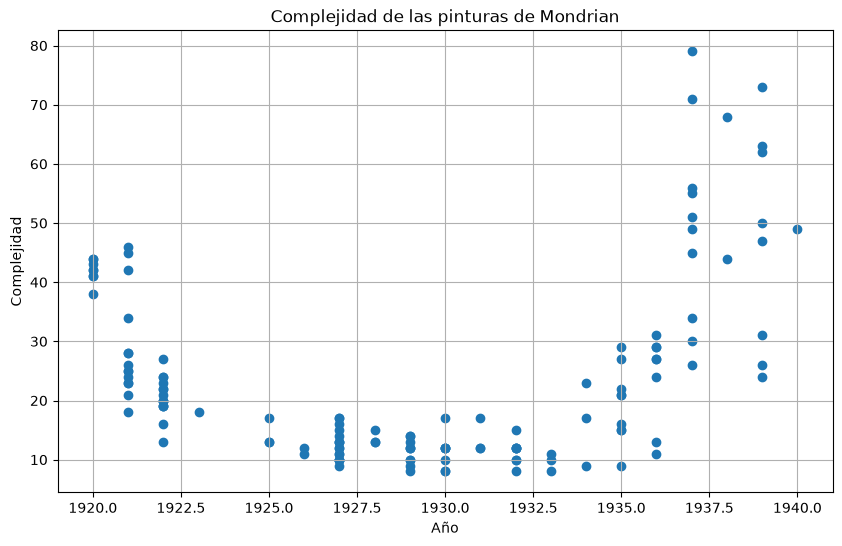

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(painting_info["year"], painting_info["complexity"])

plt.title("Complejidad de las pinturas de Mondrian")
plt.xlabel("Año")
plt.ylabel("Complejidad")

plt.grid(True)

plt.show()

## Estadísticas de la complejidad

Antes de comparar la pintura fp26, voy a calcular algunas estadísticas básicas sobre la complejidad de las pinturas de Mondrian.

In [23]:
print("Complejidad media:", painting_info["complexity"].mean())
print("Complejidad mínima:", painting_info["complexity"].min())
print("Complejidad máxima:", painting_info["complexity"].max())

Complejidad media: 23.558823529411764
Complejidad mínima: 8
Complejidad máxima: 79


## Pinturas más complejas

Ahora ordeno las pinturas por complejidad para identificar cuáles contienen un mayor número de elementos.

In [24]:
painting_info.sort_values(
    by="complexity",
    ascending=False
).head(10)

,painting_id,year,title,width,height,complexity
123,b280,1937,Composition no. 12,605,620,79
128,b286,1939,Composition no. 5,650,750,73
122,b279,1937,"Composition with Yellow, Blue and Red",690,725,71
125,b283,1938,Place de la Concorde,944,940,68
129,b287,1939,Composition no. 9,740,797,63
133,b294,1939,Trafalgar Square,1200,1452,62
120,b276,1937,Rythme de lignes droites,695,722,56
118,b274,1937,No. II: Blanc et rouge,552,603,55
121,b277,1937,Composition de lignes et couleur: III,770,800,51
130,b288,1939,Composition no. 10,730,795,50


## Complejidad de la pintura fp26

Ahora calculo la complejidad de la pintura fp26 utilizando el mismo criterio empleado para las pinturas de Mondrian.

In [20]:
fp26_complexity = len(fp26_features)

print("Complejidad de fp26:", fp26_complexity)

Complejidad de fp26: 54


## Comparación con la pintura fp26

Por último, añado la pintura fp26 al gráfico para comprobar visualmente si su complejidad es similar a la de las obras reales realizadas en esa época.


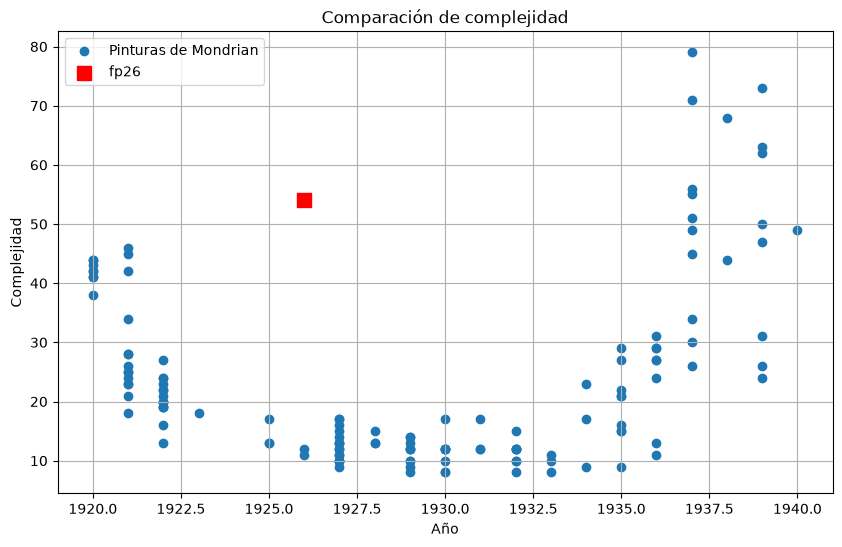

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(
    painting_info["year"],
    painting_info["complexity"],
    label="Pinturas de Mondrian"
)

plt.scatter(
    1926,
    fp26_complexity,
    color="red",
    marker="s",
    s=100,
    label="fp26"
)

plt.title("Comparación de complejidad")
plt.xlabel("Año")
plt.ylabel("Complejidad")

plt.legend()

plt.grid(True)

plt.savefig("../images/complexity_comparison.png")

plt.show()

## Comparación con la media

Comparo la complejidad de la pintura fp26 con la complejidad media de las obras de Mondrian.


In [25]:
average_complexity = painting_info["complexity"].mean()

difference = fp26_complexity - average_complexity

print("Complejidad media:", round(average_complexity, 2))
print("Complejidad de fp26:", fp26_complexity)
print("Diferencia:", round(difference, 2))

Complejidad media: 23.56
Complejidad de fp26: 54
Diferencia: 30.44


In [26]:
if fp26_complexity > average_complexity:
    print("La pintura fp26 tiene una complejidad superior a la media.")
else:
    print("La pintura fp26 tiene una complejidad inferior o igual a la media.")

La pintura fp26 tiene una complejidad superior a la media.


## Conclusión

En este proyecto he analizado la complejidad de varias pinturas de Piet Mondrian utilizando Python, Pandas y Matplotlib.

Después de calcular la complejidad de cada obra y compararla con la pintura fp26, he observado que esta presenta un número de elementos superior a la media de las pinturas analizadas.

Aunque este análisis por sí solo no permite afirmar que la pintura sea falsa, sí muestra que tiene unas características diferentes respecto a muchas obras de Mondrian. Para llegar a una conclusión definitiva sería necesario realizar otros análisis además de la complejidad.